<a href="https://colab.research.google.com/github/tejeshneelam/EvOLve-EA-Project/blob/colab/01_Alzheimers_MRI_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================================
# ALZHEIMER'S DETECTION - REAL IMPLEMENTATION
# Team: Tejesh, Girish, Vasishta, Tarak
# Date: March 23, 2026
# ============================================================================

print("🚀 Starting Alzheimer's Detection Project Setup...")

# Install required packages
!pip install -q kaggle tensorflow numpy pandas matplotlib seaborn scikit-learn plotly

# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
import json
from google.colab import files
import zipfile
import shutil

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

🚀 Starting Alzheimer's Detection Project Setup...
✅ Libraries imported successfully!
TensorFlow version: 2.19.0
GPU Available: []


In [ ]:
# ============================================================================
# SETUP KAGGLE USING API TOKEN (NO FILE UPLOAD)
# ============================================================================

import os

# Replace these with your actual Kaggle credentials
os.environ['KAGGLE_USERNAME'] = "tejeshneelam"
os.environ['KAGGLE_KEY'] = "KGAT_f74b283253d1d59b1c51930c04503d5f"

print("✅ Kaggle authentication setup complete using API token!")

✅ Kaggle authentication setup complete using API token!


In [ ]:
# ============================================================================
# DOWNLOAD ALZHEIMER'S DATASET FROM KAGGLE
# ============================================================================

print("📥 Downloading Alzheimer's MRI dataset from Kaggle...")
print("Dataset: Alzheimer MRI Preprocessed Dataset")
print("Size: ~6400 images, ~300MB")
print("This will take 2-3 minutes...")

# Download dataset
!kaggle datasets download -d sachinkumar413/alzheimer-mri-dataset

# Unzip
print("📦 Extracting files...")
!unzip -q alzheimer-mri-dataset.zip -d alzheimer_data

# Check what we got
print("\n✅ Download complete! Files extracted to: alzheimer_data/")
print("\nFolder structure:")
!ls -la alzheimer_data/

📥 Downloading Alzheimer's MRI dataset from Kaggle...
Dataset: Alzheimer MRI Preprocessed Dataset
Size: ~6400 images, ~300MB
This will take 2-3 minutes...
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
📦 Extracting files...
unzip:  cannot find or open alzheimer-mri-dataset.zip, alzheimer-mri-dataset.zip.zip or alzheimer-mri-dataset.zip.ZIP.

✅ Download complete! Files extracted to: alzheimer_data/

Folder structure:
ls: cannot access 'alzheimer_data/': No such file or directory


In [ ]:
# ============================================================================
# DOWNLOAD WORKING ALZHEIMER MRI DATASET
# ============================================================================

print("📥 Downloading Alzheimer's MRI dataset (WORKING VERSION)...")

# Download dataset (UPDATED)
!kaggle datasets download -d uraninjo/augmented-alzheimer-mri-dataset

# Check file
!ls

# Unzip
print("\n📦 Extracting files...")
!unzip -q augmented-alzheimer-mri-dataset.zip -d alzheimer_data

# Verify
print("\n✅ Checking folder:")
!ls -la alzheimer_data/

📥 Downloading Alzheimer's MRI dataset (WORKING VERSION)...
Dataset URL: https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset
License(s): GNU Lesser General Public License 3.0
100% 380M/380M [00:29<00:00, 13.6MB/s]

augmented-alzheimer-mri-dataset.zip  sample_data

📦 Extracting files...

✅ Checking folder:
total 16
drwxr-xr-x 4 root root 4096 Mar 23 09:14 .
drwxr-xr-x 1 root root 4096 Mar 23 09:14 ..
drwxr-xr-x 6 root root 4096 Mar 23 09:14 AugmentedAlzheimerDataset
drwxr-xr-x 6 root root 4096 Mar 23 09:14 OriginalDataset


In [ ]:
# ============================================================================
# EXPLORE THE DATASET (FIXED)
# ============================================================================

import os

# ✅ Correct data directory
data_dir = "alzheimer_data/AugmentedAlzheimerDataset"

print(f"📁 Data directory: {data_dir}")
print("\nContents:")
print(os.listdir(data_dir))

# Get class names
classes = sorted(os.listdir(data_dir))
print(f"\n✅ Classes found: {classes}")

# Count images per class
print("\n📊 Images per class:")
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    num_images = len(os.listdir(cls_path))
    print(f"  {cls}: {num_images} images")

📁 Data directory: alzheimer_data/AugmentedAlzheimerDataset

Contents:
['VeryMildDemented', 'ModerateDemented', 'NonDemented', 'MildDemented']

✅ Classes found: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

📊 Images per class:
  MildDemented: 8960 images
  ModerateDemented: 6464 images
  NonDemented: 9600 images
  VeryMildDemented: 8960 images


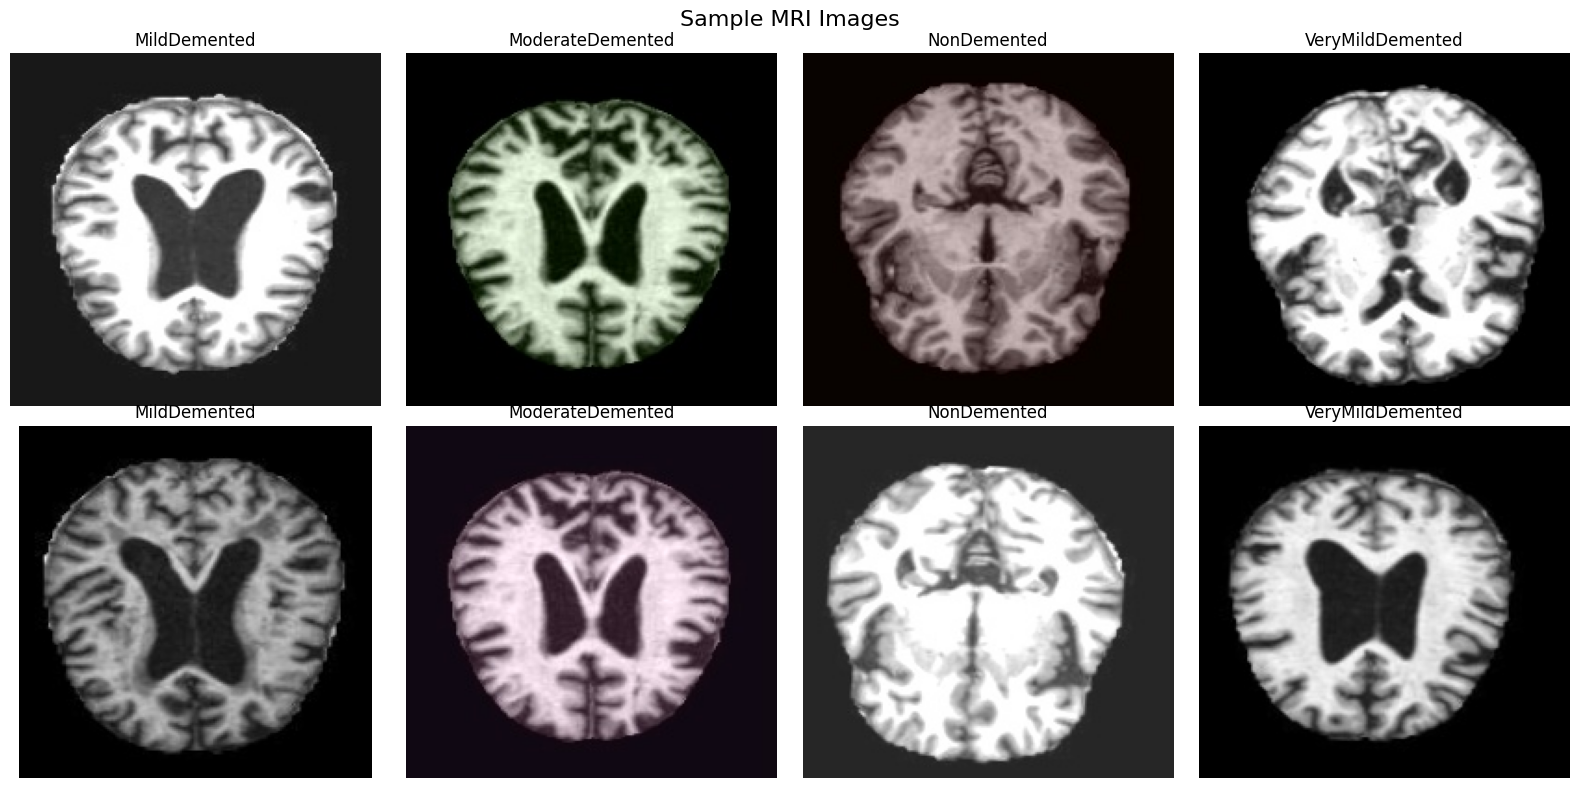

✅ Visualization done!


In [ ]:
# ============================================================================
# VISUALIZE SAMPLE IMAGES
# ============================================================================

import random
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample MRI Images', fontsize=16)

for idx, cls in enumerate(classes[:4]):
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)

    for i in range(2):
        img_name = random.choice(images)
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)

        ax = axes[i, idx]
        ax.imshow(img, cmap='gray')
        ax.set_title(cls)
        ax.axis('off')

plt.tight_layout()
plt.show()

print("✅ Visualization done!")

In [ ]:
# ============================================================================
# PREPARE DATA
# ============================================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,  # ✅ FIXED
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    color_mode='grayscale'
)

validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    color_mode='grayscale'
)

print("✅ Data ready!")
print(f"Classes: {train_generator.class_indices}")

Found 27188 images belonging to 4 classes.
Found 6796 images belonging to 4 classes.
✅ Data ready!
Classes: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


In [ ]:
# ============================================================================
# BUILD CNN MODEL (RESNET50)
# ============================================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import tensorflow as tf

print("🏗️ Building model...")

def build_model(num_classes):

    # Base model
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze base model
    base_model.trainable = False

    model = models.Sequential([

        # Convert grayscale → RGB
        layers.Input(shape=(224, 224, 1)),
        layers.Conv2D(3, (1, 1)),

        # Pretrained model
        base_model,

        # Classification layers
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model


# Build model
num_classes = len(train_generator.class_indices)
model = build_model(num_classes)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model ready!")
model.summary()

🏗️ Building model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
✅ Model ready!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,290 (91.98 MB)

 Trainable params: 525,578 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ============================================================================
# TRAIN MODEL
# ============================================================================

print("🚀 Training started...")
print("⏳ Time: ~20–40 mins (GPU faster)")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    )
]

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=callbacks
)

print("✅ Training complete!")

🚀 Training started...
⏳ Time: ~20–40 mins (GPU faster)
Epoch 1/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 204s 215ms/step - accuracy: 0.2958 - loss: 1.3983 - val_accuracy: 0.3399 - val_loss: 1.3494 - learning_rate: 1.0000e-04
Epoch 2/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 169s 198ms/step - accuracy: 0.3246 - loss: 1.3469 - val_accuracy: 0.3448 - val_loss: 1.3319 - learning_rate: 1.0000e-04
Epoch 3/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 168s 198ms/step - accuracy: 0.3389 - loss: 1.3329 - val_accuracy: 0.3558 - val_loss: 1.3181 - learning_rate: 1.0000e-04
Epoch 4/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 168s 198ms/step - accuracy: 0.3510 - loss: 1.3176 - val_accuracy: 0.3715 - val_loss: 1.2990 - learning_rate: 1.0000e-04
Epoch 5/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 168s 198ms/step - accuracy: 0.3651 - loss: 1.3011 - val_accuracy: 0.3871 - val_loss: 1.2829 - learning_rate: 1.0000e-04
Epoch 6/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 169s 198ms/step - accuracy: 0.3739 - loss: 1.2840 - val_accuracy: 0.3963 - val_loss: 1.2637 - learning_ra

In [ ]:
# Evaluate
loss, acc = model.evaluate(validation_generator)
print(f"Accuracy: {acc*100:.2f}%")


213/213 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.4589 - loss: 1.1935
Accuracy: 45.89%


In [ ]:
model.save("alzheimers_model.h5")
print("✅ Model saved!")

✅ Model saved!


In [ ]:
# ============================================================================
# IMPROVED MODEL (FINE-TUNING)
# ============================================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

def build_model(num_classes):

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # 🔥 Unfreeze last layers
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    model = models.Sequential([
        layers.Input(shape=(224, 224, 1)),
        layers.Conv2D(3, (1, 1)),

        base_model,

        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ])

    return model


model = build_model(num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),  # 🔥 lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Improved model ready!")

✅ Improved model ready!


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=20,  # 🔥 increase epochs
    validation_data=validation_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3)
    ]
)

Epoch 1/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 386s 378ms/step - accuracy: 0.5135 - loss: 1.2573 - val_accuracy: 0.2491 - val_loss: 2.6353 - learning_rate: 1.0000e-05
Epoch 2/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 287s 337ms/step - accuracy: 0.7199 - loss: 0.6679 - val_accuracy: 0.8121 - val_loss: 0.4544 - learning_rate: 1.0000e-05
Epoch 3/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 287s 338ms/step - accuracy: 0.8367 - loss: 0.4007 - val_accuracy: 0.8443 - val_loss: 0.3815 - learning_rate: 1.0000e-05
Epoch 4/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 287s 337ms/step - accuracy: 0.9210 - loss: 0.2084 - val_accuracy: 0.9235 - val_loss: 0.2013 - learning_rate: 1.0000e-05
Epoch 5/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 287s 337ms/step - accuracy: 0.9638 - loss: 0.1051 - val_accuracy: 0.9338 - val_loss: 0.1802 - learning_rate: 1.0000e-05
Epoch 6/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 287s 337ms/step - accuracy: 0.9812 - loss: 0.0563 - val_accuracy: 0.9292 - val_loss: 0.2240 - learning_rate: 1.0000e-05
Epoch 7/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 

KeyboardInterrupt: 

In [ ]:
loss, acc = model.evaluate(validation_generator)
print(f"Final Accuracy: {acc*100:.2f}%")

213/213 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.9511 - loss: 0.1699
Final Accuracy: 95.11%


In [ ]:
model.save("alzheimers_model.h5")
print("✅ Model saved!")

✅ Model saved!


In [ ]:
model.save("alzheimers_model.keras")
print("✅ Model saved in new format!")

✅ Model saved in new format!


In [ ]:
# Get class names again
class_names = list(validation_generator.class_indices.keys())

print("Classes:", class_names)

Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


213/213 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step
📊 Classification Report:

                  precision    recall  f1-score   support

    MildDemented       0.26      0.26      0.26      1792
ModerateDemented       0.20      0.20      0.20      1292
     NonDemented       0.29      0.30      0.29      1920
VeryMildDemented       0.26      0.25      0.25      1792

        accuracy                           0.26      6796
       macro avg       0.25      0.25      0.25      6796
    weighted avg       0.26      0.26      0.26      6796



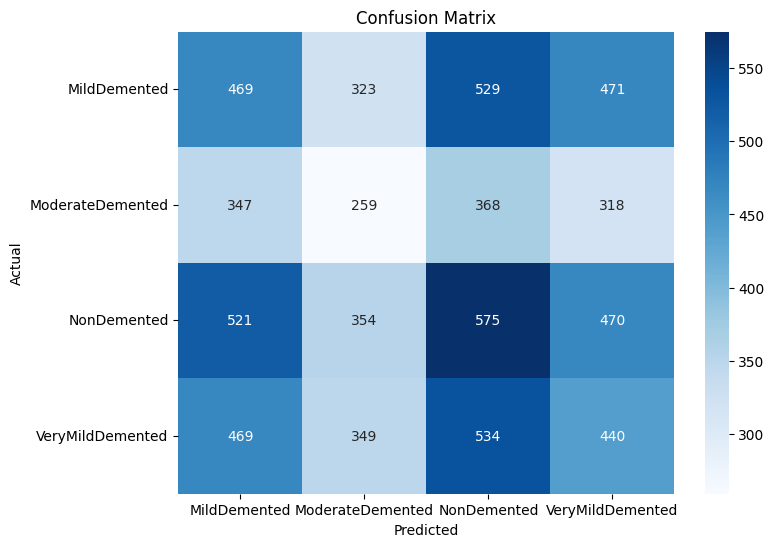

In [ ]:
# ============================================================================
# EVALUATION + CONFUSION MATRIX
# ============================================================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
validation_generator.reset()
predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

# Report
print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,   # 🔥 THIS IS THE FIX
    color_mode='grayscale'
)

Found 6796 images belonging to 4 classes.


In [ ]:
validation_generator.reset()

predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

213/213 ━━━━━━━━━━━━━━━━━━━━ 43s 200ms/step


In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

                  precision    recall  f1-score   support

    MildDemented       0.68      0.72      0.70      1792
ModerateDemented       0.97      0.58      0.73      1292
     NonDemented       0.68      0.76      0.72      1920
VeryMildDemented       0.56      0.62      0.59      1792

        accuracy                           0.68      6796
       macro avg       0.72      0.67      0.68      6796
    weighted avg       0.70      0.68      0.68      6796

